Mise en place de trading patterns

In [1]:
# %pip install pandas-ta-classic
# %pip install pandas-ta
# %pip install optuna
# %pip install candlestick-patterns-subodh101
# %pip install mplfinance

In [2]:
%load_ext autoreload
%autoreload 2
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_ta as ta
import scipy
import sys
import os
import copy
import optuna
import datetime
import itertools
from tqdm import tqdm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score,roc_auc_score
from sklearn.model_selection import cross_val_score
import Backtest_training_frequency 
sys.path.append(os.getcwd()) 
from optimi import merge_pattern_df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def choose_path(candidates):
    import os
    for p in candidates:
        if os.path.exists(p):
            return p
    return candidates[-1]
path_returns = choose_path([r"C:\\GoogleDrive\\TP\\screen\\returns.pkl", r"\\\\groupe-ufg.com\\commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_EQUITY\\0_RETURNS\\returns.pkl"]) 
returns = pd.read_pickle(path_returns) 
liste_noire =r"\\groupe-ufg.com\\commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_BASE\\_ ESG DATA\\Liste_Noire_Exclusion.xlsx"
secto_eu = pd.read_excel(r"\\groupe-ufg.com\\Commun\\Prive\\GestionAM\\PROD\\_EQUITY\\0_PTF_BLOOM\\reco_secto_facto.xlsx", sheet_name="secto_eu", index_col=0)
secto_eu = secto_eu/5*3
screen_path = choose_path([r"C:\\GoogleDrive\\TP\\screen\\screen_aggregate.pkl", r"\\\\groupe-ufg.com\\commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_EQUITY\\0_SCREEN_AGG\\backup_screen\\screen_aggregate_20250605_before_cyc.pkl"])
screen_agg = pd.read_pickle(screen_path)
df=pd.read_pickle(r"\\groupe-ufg.COM\\Commun\\Prive\\GestionAM\\Ingenierie_Financiere\\DOSSIERS_UTILISATEURS\\Yannick\\screen_ML_prod_EU.pkl")

Les Trading_patterns sont stockés dans un pickle

In [4]:
#data=merge_pattern_df(df,returns) # 10 min
data=pd.read_pickle("screen_patterns_eu.pkl")

## Etude de la corrélation des patterns avec la target

In [6]:
label='information_ratio 1.0M'

fondamental_var=[  
                'Dividend Avg Percentile',
                'Value Avg Percentile',
                'Quality Avg Percentile',
                'Mom Avg Percentile',
                'LowVol Avg Percentile',
                'Growth Avg Percentile',
                'Value Avg Percentile_change_1M',
                'Quality Avg Percentile_change_1M',
                'Growth Avg Percentile_change_1M',
                'Value Avg Percentile_change_3M',
                'Quality Avg Percentile_change_3M',
                'Growth Avg Percentile_change_3M',
                'Value Avg Percentile_change_6M',
                'Quality Avg Percentile_change_6M',
                'Growth Avg Percentile_change_6M',
                'Value Avg Percentile_change_12M',
                'Quality Avg Percentile_change_12M',
                'Growth Avg Percentile_change_12M',
                ]

technical_var=[ 
                'wedge_pattern', 
                'head_shoulder_pattern',
                'triangle_pattern',
                'channel_pattern',
                'double_pattern', 
                # 'slope',
                # 'support',
                # 'resistance',
                # 'support_bis',
                # 'resistance_bis',
                'signal', 
                'BearishEngulfing',
                'BearishHarami',
                'BullishEngulfing',
                'BullishHarami',
                'DarkCloudCover',
                'Doji',
                'Hammer',
                'HangingMan',
                'InvertedHammer',
                'MorningStar',
                'PiercingPattern',
                'ShootingStar',
                'rsi',
                'atr',
                'ema', 
                'fwma', # fibbonacci weighted moving average
                # 'momentum',
                'MACD_12_26_9', #EMA_12-EMA_26
                # 'MACDs_12_26_9', # EMA_9
                'MACDh_12_26_9', # MACD_12_26_9-MACDs_12_26_9
                # 'stdev',
                # 'entropy',
                # 'skew',
                'PSARl_0.02_0.2',
                'PSARs_0.02_0.2',
                'PSARaf_0.02_0.2',
                'PSARr_0.02_0.2',
                'BBL_5_2.0',
                'BBM_5_2.0',
                'BBU_5_2.0',
                'BBB_5_2.0',
                'BBP_5_2.0'
                ]


start_date='2005-01-01'
split_date=pd.to_datetime('2010-01-01')
end_date='2015-01-01'
col_object=data[technical_var].select_dtypes(include='object').columns
col_bool=data[technical_var].select_dtypes(include='bool').columns
data[col_bool]=data[col_bool].astype(int)
data[col_object]=data[col_object].replace({'':'Nothing',np.nan:'Nothing'})
data=data.dropna(subset=label)

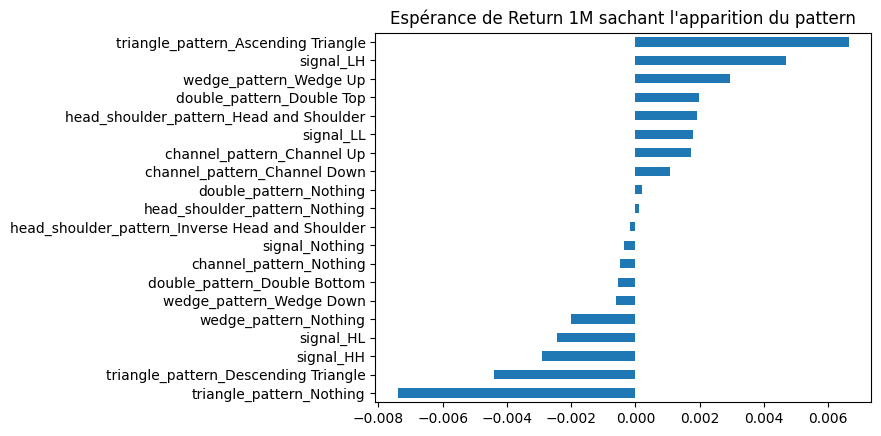

In [7]:
pd.get_dummies(data[technical_var].select_dtypes(include='object')).replace({True:1,False:0}).apply(lambda x:sum(x*data[label].values)/sum(x)).sort_values(ascending=True).plot(kind='barh')
plt.title("Espérance de Return 1M sachant l'apparition du pattern")
plt.show()

In [8]:
# preprocessing
boolmask=(data.reset_index()['Date']<end_date)&(data.reset_index()['Date']>=start_date)
Y=data.loc[boolmask.values, label]
X=data.loc[boolmask.values,fondamental_var+technical_var]
numerical_features=list(X.select_dtypes(exclude='object').columns)
categorical_features=list(X.select_dtypes(include='object').columns)


numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  OneHotEncoder(handle_unknown='ignore', drop='first',
            sparse_output=False,
            dtype=int),)])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

X_train,X_test=X.loc[X.index.get_level_values(1)<split_date],X.loc[X.index.get_level_values(1)>=split_date]
y_train,y_test=Y.loc[X_train.index].values,Y.loc[X_test.index].values

In [9]:
X_train=preprocessor.fit_transform(X_train.reset_index().drop(['Date','Company SEDOL'],axis=1))
X_test=preprocessor.transform(X_test.reset_index().drop(['Date','Company SEDOL'],axis=1))

# reshape y
y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)

In [11]:
def hyperparameters_tuning(X,Y,model_name,n_trial,cv=5):
    def objective(trial):
        if model_name=='Random Forest':
            parameters={'max_depth': trial.suggest_int('max_depth',5,10),
                        'max_features': trial.suggest_float('max_features', 0.2,0.8),
                        'criterion': trial.suggest_categorical('criterion',['gini','entropy']),
                        'min_samples_split':trial.suggest_float('min_samples_split',0.001,0.01),
                        'random_state':42,
                        'n_jobs':-1,
                        'n_estimators': 100
                        }
            model=RandomForestClassifier(**parameters)
        elif model_name=='XGBOOST':
            parameters={'max_depth': trial.suggest_int('max_depth',3,7),
                        'max_features': trial.suggest_float('max_features', 0.2,0.6),
                        'criterion': trial.suggest_categorical('criterion',['gini','entropy']),
                        'learning_rate':trial.suggest_float('learning_rate',0.01,0.3),
                        'reg_alpha': trial.suggest_float('reg_alpha',0.1,5),
                        'reg_lambda': trial.suggest_float('reg_lambda',0.1,5),
                        'max_iterations': trial.suggest_int('max_iterations',20,100),
                        'random_state':42,
                        #'n_estimators': trial.suggest_int('n_estimators',5,10),
                        #'colsample_bytree': trial.suggest_float('colsample_bytree',0.2,1),
                        'objective': 'binary:logistic',
                        }
            model=XGBClassifier(**parameters)
        return cross_val_score(model, X, Y, n_jobs=-1, cv=cv,scoring='f1').mean()
        
    study=optuna.create_study(direction='maximize')
    study.optimize(objective,n_trials=n_trial)
    print(study.best_params)
    return study.best_params


In [12]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'Random Forest',20)

[I 2025-10-07 15:22:09,957] A new study created in memory with name: no-name-183885dd-24c3-4d35-908d-2cc300ea36ca
[I 2025-10-07 15:22:44,546] Trial 0 finished with value: 0.5196754014619509 and parameters: {'max_depth': 9, 'max_features': 0.5826722496951917, 'criterion': 'gini', 'min_samples_split': 0.007187516153464358}. Best is trial 0 with value: 0.5196754014619509.
[I 2025-10-07 15:23:09,557] Trial 1 finished with value: 0.5404394080653605 and parameters: {'max_depth': 5, 'max_features': 0.6511930669690487, 'criterion': 'gini', 'min_samples_split': 0.0031866220763778442}. Best is trial 1 with value: 0.5404394080653605.
[I 2025-10-07 15:23:34,270] Trial 2 finished with value: 0.5391778264710954 and parameters: {'max_depth': 6, 'max_features': 0.38909768972358005, 'criterion': 'entropy', 'min_samples_split': 0.0012809575967536503}. Best is trial 1 with value: 0.5404394080653605.
[I 2025-10-07 15:23:51,777] Trial 3 finished with value: 0.5178489647588502 and parameters: {'max_depth': 

{'max_depth': 5, 'max_features': 0.7303106636550663, 'criterion': 'gini', 'min_samples_split': 0.0021128358409883943}


params_rf={'max_depth': 5, 'max_features': 0.7861012995390931, 'criterion': 'gini', 'min_samples_split': 0.0029719729957510266}


In [15]:
params_rf={'max_depth': 5, 'max_features': 0.7861012995390931, 'criterion': 'gini', 'min_samples_split': 0.0029719729957510266}

In [16]:
rf=RandomForestClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
rf.fit(X_train,(y_train>0).astype(int))
feature_name=list(preprocessor.transformers_[1][1]['scaler'].get_feature_names_out(categorical_features))+list(numerical_features)
pd.DataFrame(rf.feature_importances_,
             index=feature_name,
             columns=['importances']).sort_values(by='importances',ascending=False)

,importances
PSARl_0.02_0.2,0.281335
rsi,0.176725
ShootingStar,0.074254
Growth Avg Percentile_change_12M,0.041534
head_shoulder_pattern_Inverse Head and Shoulder,0.027236
signal_HL,0.026499
Value Avg Percentile_change_6M,0.024147
signal_LH,0.020496
BullishHarami,0.020359
signal_Nothing,0.019475


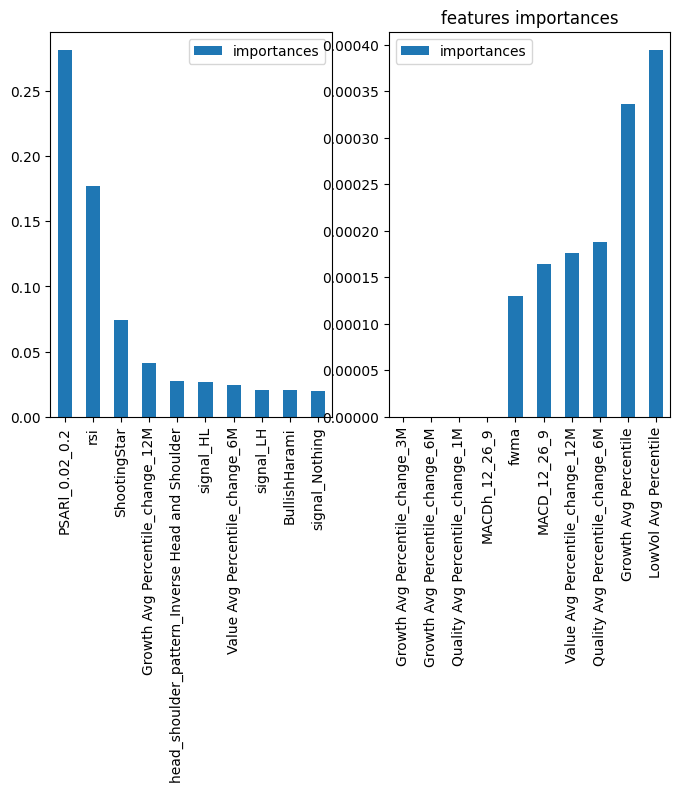

In [17]:
fig,ax=plt.subplots(1,2,figsize=(8,5))
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)[:10].plot(kind='bar',ax=ax[0])
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=True)[:10].plot(kind='bar',ax=ax[1])
plt.title('features importances')
plt.show()

In [18]:
pred=rf.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5487776885114197, accuracy: 0.5543780107679229, auc:0.5487523107574621 


array([[9344, 8043],
       [7683, 9782]])

In [31]:
model=RandomForestClassifier(**params_rf,n_estimators=100,n_jobs=-1,random_state=42)
features=numerical_features+categorical_features
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_eu,liste_noire,
                                                            features,label,percentile=0.1,
                                                            ponderation="Racine cube",esg_exclusion=0)


100%|██████████| 11/11 [02:42<00:00, 14.77s/it]


In [33]:
screen

,PTF,ISIN,Weight,Date,Secto,Score
0,ML EU Q1,DE0005470405,0.016474,2015-02-01,4.0,1.000000
1,ML EU Q1,DK0060636678,0.014148,2015-02-01,10.0,1.000000
2,ML EU Q1,SE0000202624,0.011327,2015-02-01,8.0,1.000000
3,ML EU Q1,FR0000077919,0.019160,2015-02-01,11.0,1.000000
4,ML EU Q1,FR0013176526,0.029412,2015-02-01,1.0,1.000000
...,...,...,...,...,...,...
6829,ML EU Q1,DK0060257814,0.026353,2025-05-01,8.0,0.923077
6830,ML EU Q1,NL0015000LU4,0.008786,2025-05-01,1.0,0.923077
6831,ML EU Q1,GB00BHJYC057,0.007234,2025-05-01,18.0,0.916667
6832,ML EU Q1,CH0038863350,0.036778,2025-05-01,7.0,0.714286


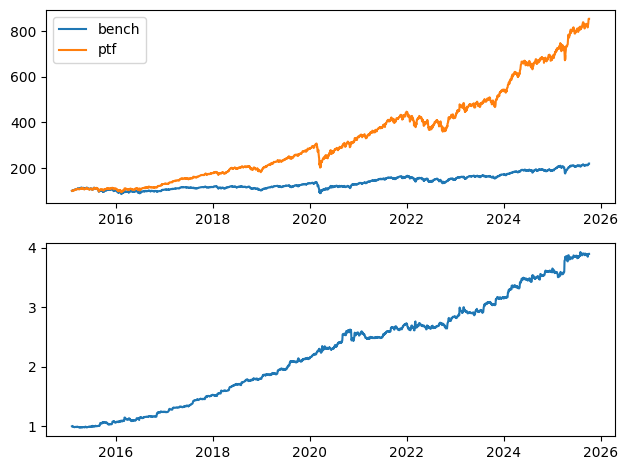

In [32]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()


In [21]:
rdt=ptf.reset_index()
rdt['year']=rdt['Date'].apply(lambda x:x.year)
rdt=rdt.groupby(by='year').agg('first')
U=np.nanmean(rdt['Contrib'].pct_change()-0.02)
std=np.nanstd(rdt['Contrib'].pct_change())
U/std

np.float64(0.8800591825127466)

<Axes: xlabel='Date'>

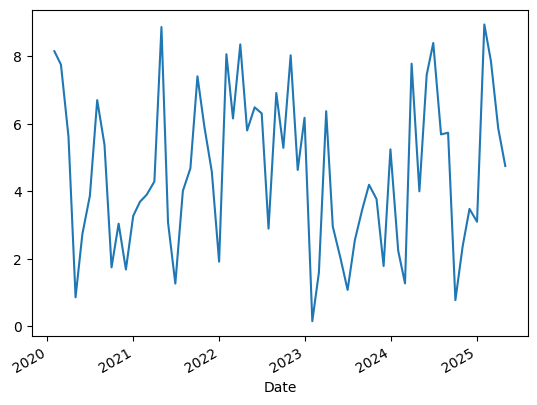

In [24]:
screen.set_index('Date')['Score ML'].plot(kind='line')

### XGBOOST

In [16]:
params_xg=hyperparameters_tuning(X_train,(y_train>0).astype(int),'XGBOOST',500)

[I 2025-09-29 09:33:32,124] A new study created in memory with name: no-name-26b353b3-9c22-4bc1-bd09-58233beff263
[I 2025-09-29 09:33:51,021] Trial 0 finished with value: 0.5067143857383778 and parameters: {'max_depth': 7, 'max_features': 0.5841889137964071, 'criterion': 'gini', 'learning_rate': 0.035051967073011794, 'reg_alpha': 4.878954568810177, 'reg_lambda': 4.663345337887529, 'max_iterations': 62}. Best is trial 0 with value: 0.5067143857383778.
[I 2025-09-29 09:33:58,722] Trial 1 finished with value: 0.501814560088702 and parameters: {'max_depth': 5, 'max_features': 0.4547366880121361, 'criterion': 'gini', 'learning_rate': 0.2764546749802688, 'reg_alpha': 2.5333830986574224, 'reg_lambda': 1.8382937508508743, 'max_iterations': 25}. Best is trial 0 with value: 0.5067143857383778.
[I 2025-09-29 09:34:04,432] Trial 2 finished with value: 0.5076302794057547 and parameters: {'max_depth': 3, 'max_features': 0.4295840534109374, 'criterion': 'entropy', 'learning_rate': 0.2454475851966403,

{'max_depth': 3, 'max_features': 0.3110290918697048, 'criterion': 'gini', 'learning_rate': 0.015511765451016828, 'reg_alpha': 1.3690024383038453, 'reg_lambda': 3.777107480288785, 'max_iterations': 32}


In [26]:
params_xg={'max_depth': 3, 'max_features': 0.3110290918697048, 'criterion': 'gini', 'learning_rate': 0.015511765451016828, 'reg_alpha': 1.3690024383038453, 'reg_lambda': 3.777107480288785, 'max_iterations': 32}
xg=XGBClassifier(**params_xg,objective='binary:logistic',random_state=42)
xg.fit(X_train,(y_train>0).astype(int))
feature_name=list(preprocessor.transformers_[1][1]['scaler'].get_feature_names_out(categorical_features))+list(numerical_features)
pd.DataFrame(xg.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)

,importances
PSARl_0.02_0.2,0.213588
rsi,0.055910
Value Avg Percentile_change_6M,0.039064
triangle_pattern_Descending Triangle,0.033819
Value Avg Percentile_change_1M,0.031588
ShootingStar,0.030314
Value Avg Percentile_change_3M,0.029483
ema,0.029101
HangingMan,0.027533
Growth Avg Percentile_change_12M,0.026374


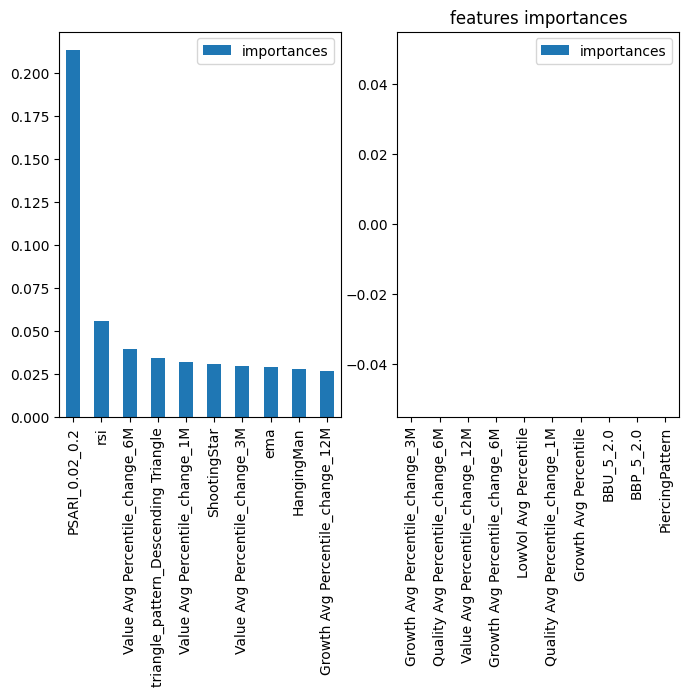

In [27]:
fig,ax=plt.subplots(1,2,figsize=(8,5))
pd.DataFrame(xg.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)[:10].plot(kind='bar',ax=ax[0])
pd.DataFrame(xg.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=True)[:10].plot(kind='bar',ax=ax[1])
plt.title('features importances')
plt.show()

In [28]:
pred=xg.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5504705612303454, accuracy: 0.5545477808421712, auc:0.5504528336265659 


array([[9433, 7954],
       [7713, 9752]])

In [29]:
model=XGBClassifier(**params_xg,objective='binary:logistic',random_state=42)
features=fondamental_var+technical_var
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_eu,liste_noire,features,label,percentile=0.1)

100%|██████████| 11/11 [00:25<00:00,  2.31s/it]


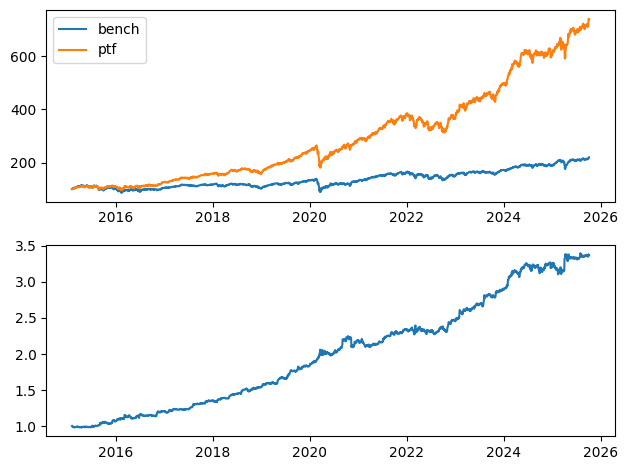

In [30]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()


In [22]:
rdt=ptf.reset_index()
rdt['year']=rdt['Date'].apply(lambda x:x.year)
rdt=rdt.groupby(by='year').agg('first')
U=np.nanmean(rdt['Contrib'].pct_change()-0.02)
std=np.nanstd(rdt['Contrib'].pct_change())
U/std

1.0746231487045446

## Variables fondamentales uniquement

In [23]:
X=data.loc[boolmask.values,fondamental_var]

numerical_features=list(X.select_dtypes(exclude='object').columns)
categorical_features=list(X.select_dtypes(include='object').columns)

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  OneHotEncoder(handle_unknown='ignore', drop='first',
            sparse_output=False,
            dtype=int))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
    ])


X_train,X_test=X.loc[X.index.get_level_values(1)<split_date],X.loc[X.index.get_level_values(1)>=split_date]
X_train=preprocessor.fit_transform(X_train.reset_index().drop(['Date','Company SEDOL'],axis=1))
X_test=preprocessor.transform(X_test.reset_index().drop(['Date','Company SEDOL'],axis=1))


In [24]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'Random Forest',100)

[I 2025-09-29 10:48:30,372] A new study created in memory with name: no-name-476aca57-ff5c-432e-b1cc-e45b24fcde9a
[I 2025-09-29 10:48:58,561] Trial 0 finished with value: 0.44388693454526207 and parameters: {'max_depth': 7, 'max_features': 0.5256020847967728, 'criterion': 'entropy', 'min_samples_split': 0.00678915659601699}. Best is trial 0 with value: 0.44388693454526207.
[I 2025-09-29 10:49:13,851] Trial 1 finished with value: 0.440382705631355 and parameters: {'max_depth': 5, 'max_features': 0.5780812196678375, 'criterion': 'gini', 'min_samples_split': 0.005266690003786668}. Best is trial 0 with value: 0.44388693454526207.
[I 2025-09-29 10:49:30,431] Trial 2 finished with value: 0.4428589381120055 and parameters: {'max_depth': 8, 'max_features': 0.6136414627689553, 'criterion': 'gini', 'min_samples_split': 0.008864882853861097}. Best is trial 0 with value: 0.44388693454526207.
[I 2025-09-29 10:49:39,996] Trial 3 finished with value: 0.44359001283154614 and parameters: {'max_depth': 

{'max_depth': 10, 'max_features': 0.7444900604415415, 'criterion': 'gini', 'min_samples_split': 0.009049676316465846}


In [12]:
params_rf={'max_depth': 10, 'max_features': 0.7444900604415415, 'criterion': 'gini', 'min_samples_split': 0.009049676316465846}

In [32]:
rf=RandomForestClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
rf.fit(X_train,(y_train>0).astype(int))
pred=rf.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5191380695512453, accuracy: 0.4568817448228927, auc:0.5193972116315221 


array([[11044,  6343],
       [10416,  7049]], dtype=int64)

In [13]:
model=RandomForestClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
features=fondamental_var
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_eu,liste_noire,features,label,percentile=0.2)

100%|██████████| 11/11 [03:11<00:00, 17.38s/it]


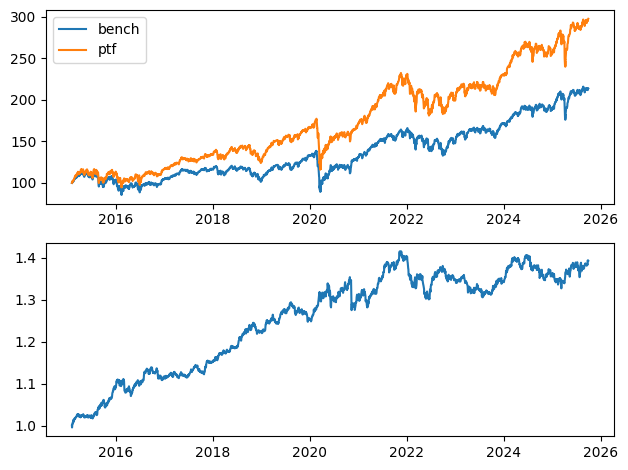

In [18]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()

In [20]:
rdt=ptf_f.reset_index()
rdt['year']=rdt['Date'].apply(lambda x:x.year)
rdt=rdt.groupby(by='year').agg('first')
U=np.nanmean(rdt['Contrib'].pct_change()-0.02)
std=np.nanstd(rdt['Contrib'].pct_change())
U/std

0.6321010671706655

In [38]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'XGBOOST',100)

[I 2025-09-29 14:25:33,390] A new study created in memory with name: no-name-26fcb3bd-8eca-4b17-8add-9902c5549e9b
[I 2025-09-29 14:26:30,966] Trial 0 finished with value: 0.47783585438990617 and parameters: {'max_depth': 7, 'max_features': 0.46520991684344787, 'criterion': 'gini', 'learning_rate': 0.13611611937906778, 'reg_alpha': 1.307225017256639, 'reg_lambda': 2.441038971602082, 'max_iterations': 53}. Best is trial 0 with value: 0.47783585438990617.
[I 2025-09-29 14:26:38,405] Trial 1 finished with value: 0.46393472854726764 and parameters: {'max_depth': 4, 'max_features': 0.4047846527089707, 'criterion': 'gini', 'learning_rate': 0.10087321323072695, 'reg_alpha': 0.364088840171119, 'reg_lambda': 4.6452897779908975, 'max_iterations': 38}. Best is trial 0 with value: 0.47783585438990617.
[I 2025-09-29 14:26:44,967] Trial 2 finished with value: 0.46177270970171536 and parameters: {'max_depth': 6, 'max_features': 0.4268972304805234, 'criterion': 'gini', 'learning_rate': 0.05819042390224

{'max_depth': 7, 'max_features': 0.21196371805081465, 'criterion': 'gini', 'learning_rate': 0.27865952207887346, 'reg_alpha': 1.301056839453547, 'reg_lambda': 1.127620934955388, 'max_iterations': 48}


In [43]:
model=XGBClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
features=fondamental_var
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_eu,liste_noire,features,label,percentile=0.1)

100%|██████████| 11/11 [00:47<00:00,  4.36s/it]


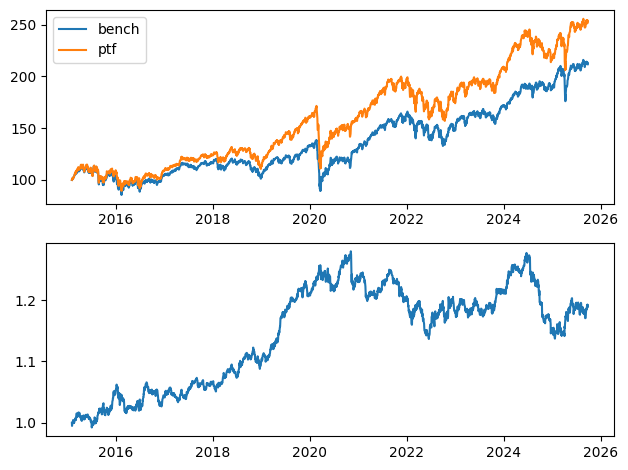

In [44]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()

### use only patterns 

In [65]:
X=data.loc[boolmask.values,technical_var]

numerical_features=list(X.select_dtypes(exclude='object').columns)
categorical_features=list(X.select_dtypes(include='object').columns)

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  OneHotEncoder(handle_unknown='ignore', drop='first',
            sparse_output=False,
            dtype=int))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

X_train,X_test=X.loc[X.index.get_level_values(1)<split_date],X.loc[X.index.get_level_values(1)>=split_date]
X_train=preprocessor.fit_transform(X_train.reset_index().drop(['Date','Company SEDOL'],axis=1))
X_test=preprocessor.transform(X_test.reset_index().drop(['Date','Company SEDOL'],axis=1))

In [46]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'Random Forest',50)

[I 2025-09-29 14:53:54,150] A new study created in memory with name: no-name-a3a93694-bc54-4fbd-9ed8-47fab20adda6
[I 2025-09-29 14:54:18,825] Trial 0 finished with value: 0.5267114961964854 and parameters: {'max_depth': 7, 'max_features': 0.265265809503615, 'criterion': 'entropy', 'min_samples_split': 0.005709636536563312}. Best is trial 0 with value: 0.5267114961964854.
[I 2025-09-29 14:54:48,673] Trial 1 finished with value: 0.5256645110657268 and parameters: {'max_depth': 8, 'max_features': 0.6171209253516875, 'criterion': 'entropy', 'min_samples_split': 0.005459425254495545}. Best is trial 0 with value: 0.5267114961964854.
[I 2025-09-29 14:55:01,311] Trial 2 finished with value: 0.5230943347148995 and parameters: {'max_depth': 7, 'max_features': 0.2626976445273235, 'criterion': 'gini', 'min_samples_split': 0.003844928769277276}. Best is trial 0 with value: 0.5267114961964854.
[I 2025-09-29 14:55:11,059] Trial 3 finished with value: 0.5330775148327825 and parameters: {'max_depth': 6

{'max_depth': 5, 'max_features': 0.6443982243913733, 'criterion': 'entropy', 'min_samples_split': 0.0050164201157322855}


In [50]:
rf=RandomForestClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
rf.fit(X_train,(y_train>0).astype(int))
pred=rf.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5498106277975439, accuracy: 0.5530933120656261, auc:0.5497969424787345 


array([[9453, 7934],
       [7756, 9709]], dtype=int64)

In [73]:
model=RandomForestClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
features=numerical_features+categorical_features
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_eu,liste_noire,features,
                                                             label,percentile=0.1,esg_exclusion=0,cut_mkt_cap=0,
                                                            #ponderation='Racine Cube'
                                                            )

100%|██████████| 11/11 [02:44<00:00, 14.99s/it]


In [30]:
# analyse des scores factoriels des boites

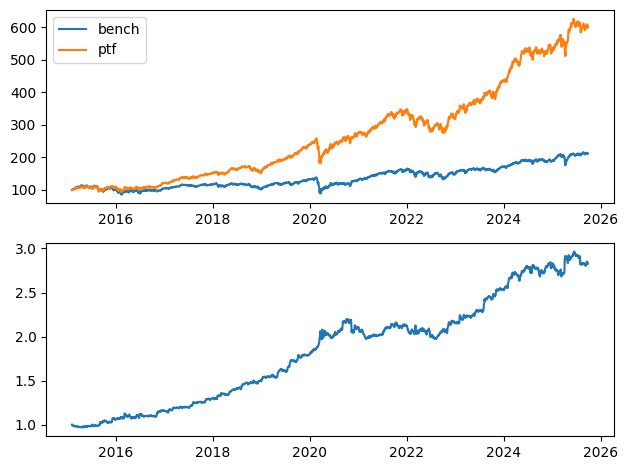

In [74]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()

In [75]:
rdt=ptf.reset_index()
rdt['year']=rdt['Date'].apply(lambda x:x.year)
rdt=rdt.groupby(by='year').agg('first')
U=np.nanmean(rdt['Contrib'].pct_change()-0.02)
std=np.nanstd(rdt['Contrib'].pct_change())
U/std

1.0329539704877526

In [76]:
model=RandomForestClassifier(**params_rf,n_jobs=-1,n_estimators=100,random_state=42)
features=numerical_features+categorical_features
bench_cap,ptf_cap,screen_cap=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_eu,liste_noire,features,
                                                             label,percentile=0.1,esg_exclusion=0,cut_mkt_cap=0,
                                                            ponderation='Market cap'
                                                            )

  0%|          | 0/11 [00:00<?, ?it/s]